Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9554 - loss: 0.1454
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9861 - loss: 0.0450
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9903 - loss: 0.0302
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9928 - loss: 0.0232
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9945 - loss: 0.0168
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9954 - loss: 0.0144
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9958 - loss: 0.0129
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9970 - loss: 0.0086
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9969 - loss: 0.0089
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9979 - loss: 0.0063
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9872 - loss: 0.0559
0.05586804077029228
0.9872000217437744
313/3

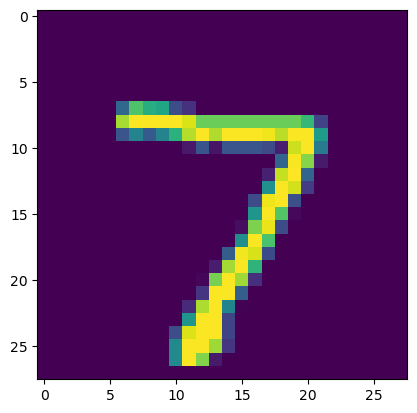

Actual: 7
Predicted: 7


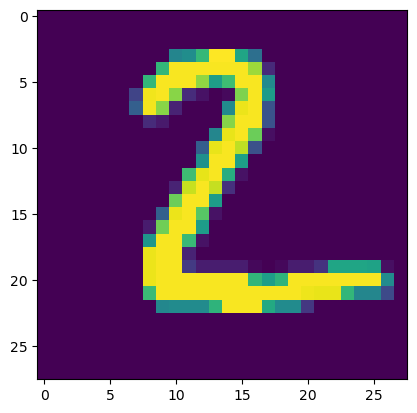

Actual: 2
Predicted: 2


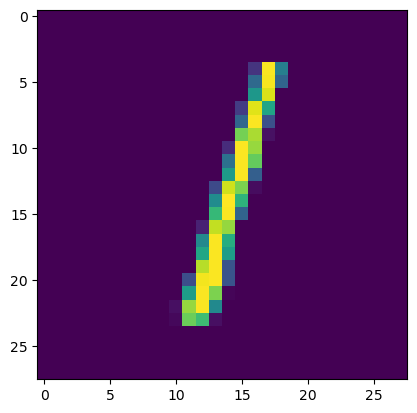

Actual: 1
Predicted: 1


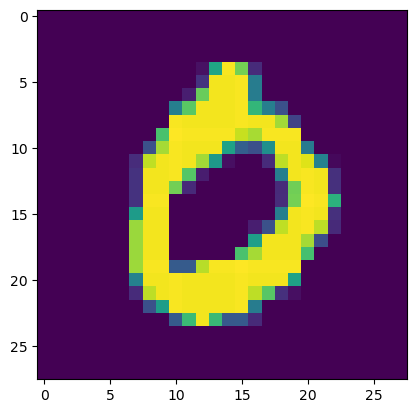

Actual: 0
Predicted: 0


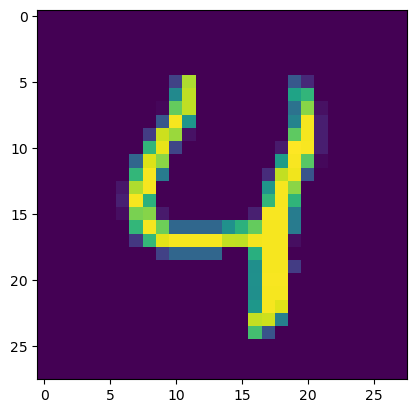

Actual: 4
Predicted: 4


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=64, epochs=10)

loss, accuracy = model.evaluate(x_test, y_test)

print(loss)
print(accuracy)

pred = model.predict(x_test)

for i in range(5):
    plt.imshow(x_test[i])
    plt.show()
    print("Actual:", np.argmax(y_test[i]))
    print("Predicted:", np.argmax(pred[i]))